In [5]:
import pandas as pd
import matplotlib.pyplot as plt

agg = pd.read_csv(r"C:\Users\bfunk\Downloads\womens_aggregated_session.csv")
sessions = pd.read_csv(r"C:\Users\bfunk\Downloads\womens_soccer_select.csv")

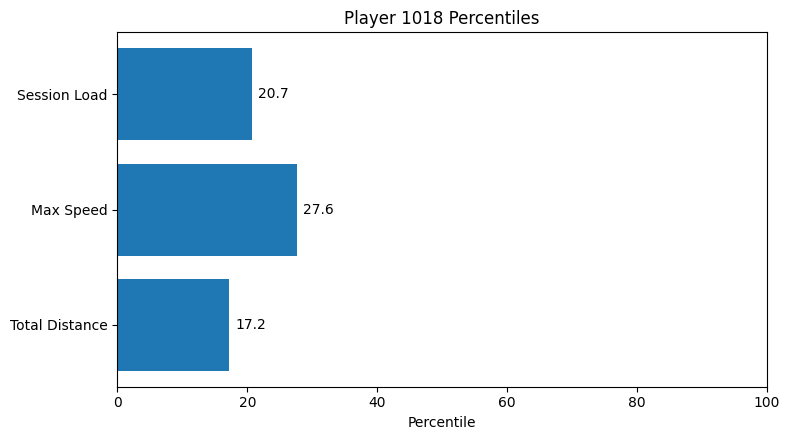

In [11]:
player_id = 1018

player = agg.loc[agg["athlete_number"] == player_id].iloc[0]

metrics = ["Total Distance", "Max Speed", "Session Load"]
percentiles = [
    player["total_dist_perc_rank"],
    player["max_speed_perc_rank"],
    player["session_load_perc_rank"]
]

plt.figure(figsize=(8, 4.5))
plt.barh(metrics, percentiles)
plt.xlim(0, 100)
plt.xlabel("Percentile")
plt.title(f"Player {player_id} Percentiles")

for i, v in enumerate(percentiles):
    plt.text(v + 1, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.show()

In [12]:
player_a = 1018
player_b = 1081

compare = agg.loc[
    agg["athlete_number"].isin([player_a, player_b]),
    ["athlete_number", "w_total_distance", "w_max_speed_kph", "w_session_load"]
].set_index("athlete_number")

print(compare)

                w_total_distance  w_max_speed_kph  w_session_load
athlete_number                                                   
1018                 3038.548302        19.773798      417.214328
1081                 4215.265913        21.609228      556.681326


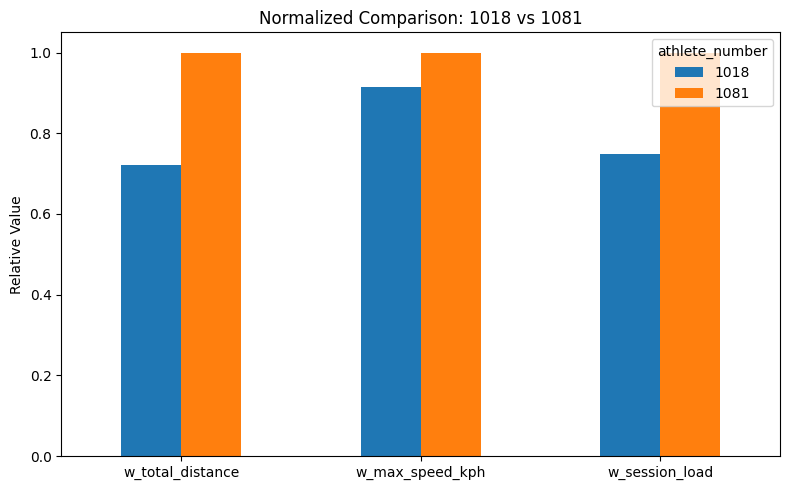

In [13]:
compare_norm = compare / compare.max()

compare_norm.T.plot(kind="bar", figsize=(8, 5))
plt.title(f"Normalized Comparison: {player_a} vs {player_b}")
plt.ylabel("Relative Value")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
agg_numeric = [
    "athlete_relative_age",
    "w_total_distance",
    "w_session_load",
    "w_max_speed_kph",
    "total_dist_perc_rank",
    "max_speed_perc_rank",
    "session_load_perc_rank",
    "num_sessions"
]

session_numeric = [
    "athlete_relative_age",
    "active_minutes",
    "total_distance_m",
    "max_speed_kph",
    "session_load",
    "total_dist_perc_rank",
    "max_speed_perc_rank",
    "session_load_perc_rank"
]

for col in agg_numeric:
    agg[col] = pd.to_numeric(agg[col], errors="coerce")

for col in session_numeric:
    sessions[col] = pd.to_numeric(sessions[col], errors="coerce")


In [16]:
print("Aggregated shape:", agg.shape)
print("Session-level shape:", sessions.shape)
print("\nAggregated columns:\n", agg.columns.tolist())
print("\nSession-level columns:\n", sessions.columns.tolist())

Aggregated shape: (94, 9)
Session-level shape: (3257, 9)

Aggregated columns:
 ['athlete_number', 'athlete_relative_age', 'w_total_distance', 'w_session_load', 'w_max_speed_kph', 'total_dist_perc_rank', 'max_speed_perc_rank', 'session_load_perc_rank', 'num_sessions']

Session-level columns:
 ['athlete_number', 'athlete_relative_age', 'active_minutes', 'total_distance_m', 'max_speed_kph', 'session_load', 'total_dist_perc_rank', 'max_speed_perc_rank', 'session_load_perc_rank']


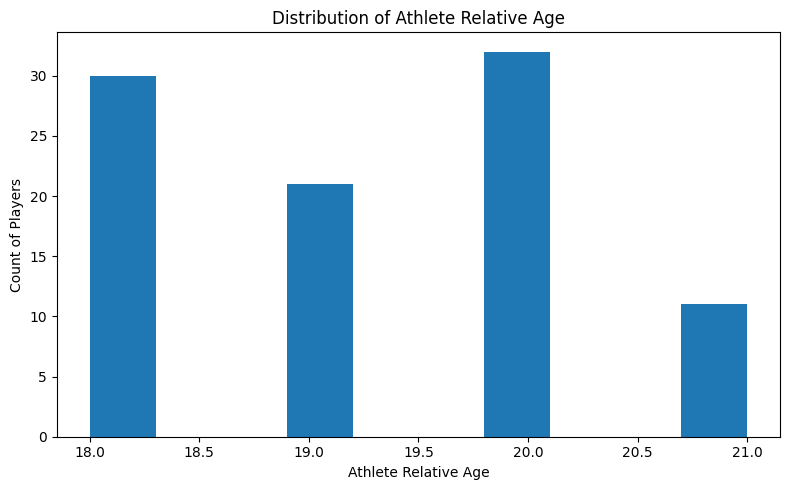

In [19]:
plt.figure(figsize=(8,5))
plt.hist(agg["athlete_relative_age"].dropna(), bins=10)
plt.title("Distribution of Athlete Relative Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Count of Players")
plt.tight_layout()
plt.show()

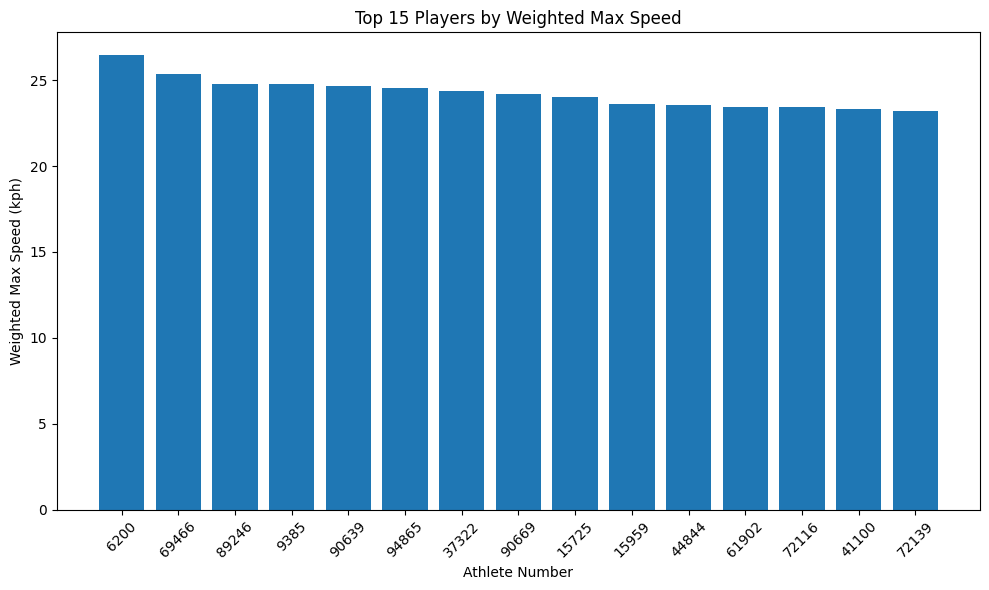

In [21]:
top_speed = agg.sort_values("w_max_speed_kph", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.bar(top_speed["athlete_number"].astype(str), top_speed["w_max_speed_kph"])
plt.title("Top 15 Players by Weighted Max Speed")
plt.xlabel("Athlete Number")
plt.ylabel("Weighted Max Speed (kph)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

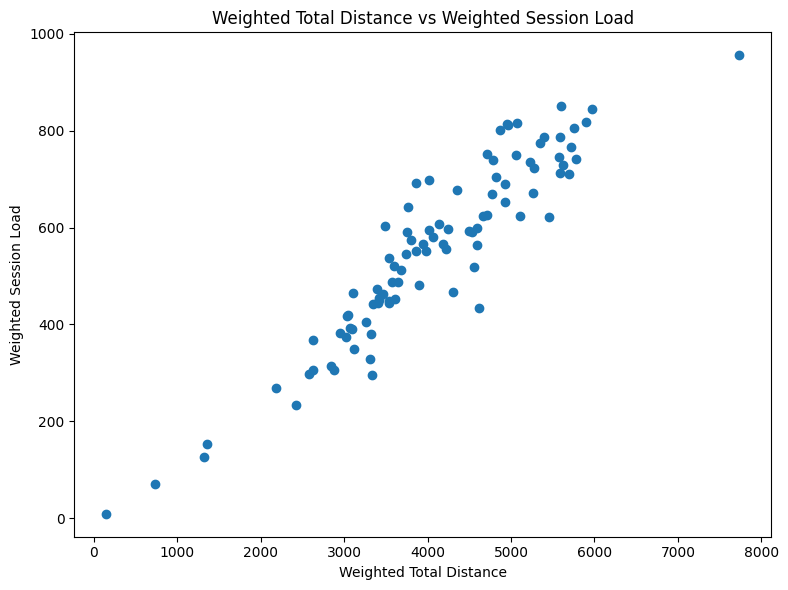

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(agg["w_total_distance"], agg["w_session_load"])
plt.title("Weighted Total Distance vs Weighted Session Load")
plt.xlabel("Weighted Total Distance")
plt.ylabel("Weighted Session Load")
plt.tight_layout()
plt.show()


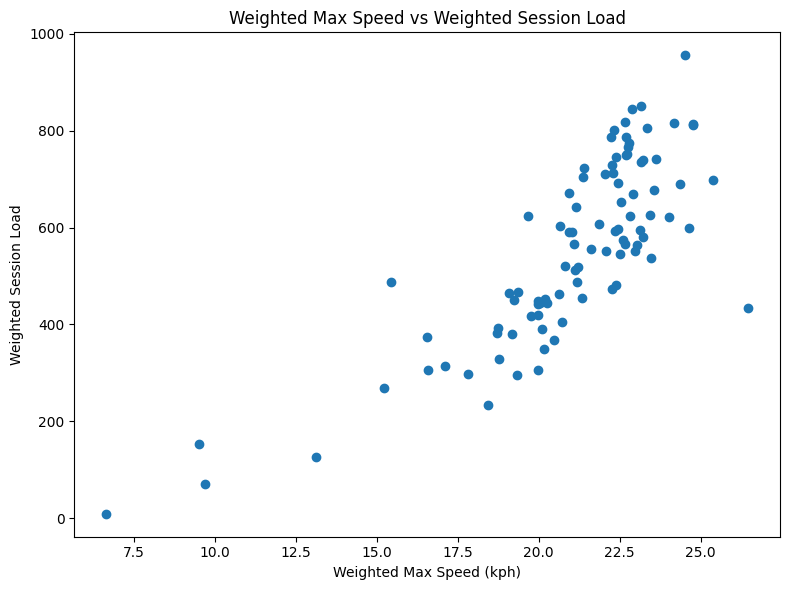

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(agg["w_max_speed_kph"], agg["w_session_load"])
plt.title("Weighted Max Speed vs Weighted Session Load")
plt.xlabel("Weighted Max Speed (kph)")
plt.ylabel("Weighted Session Load")
plt.tight_layout()
plt.show()


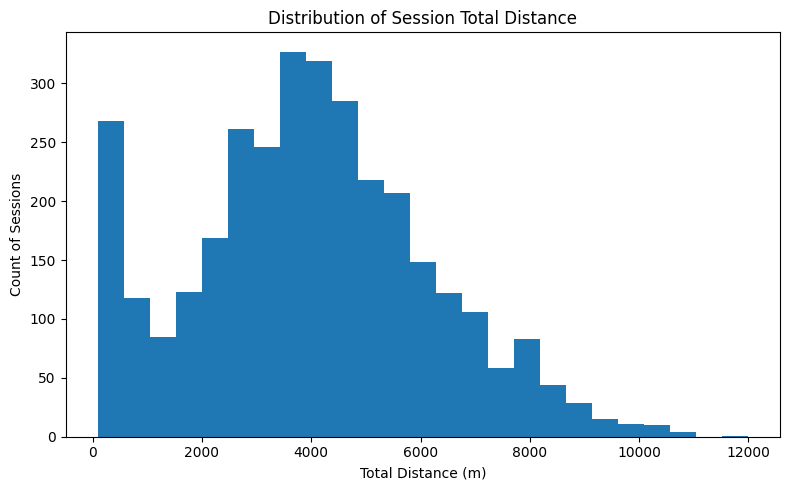

In [24]:
plt.figure(figsize=(8,5))
plt.hist(sessions["total_distance_m"].dropna(), bins=25)
plt.title("Distribution of Session Total Distance")
plt.xlabel("Total Distance (m)")
plt.ylabel("Count of Sessions")
plt.tight_layout()
plt.show()

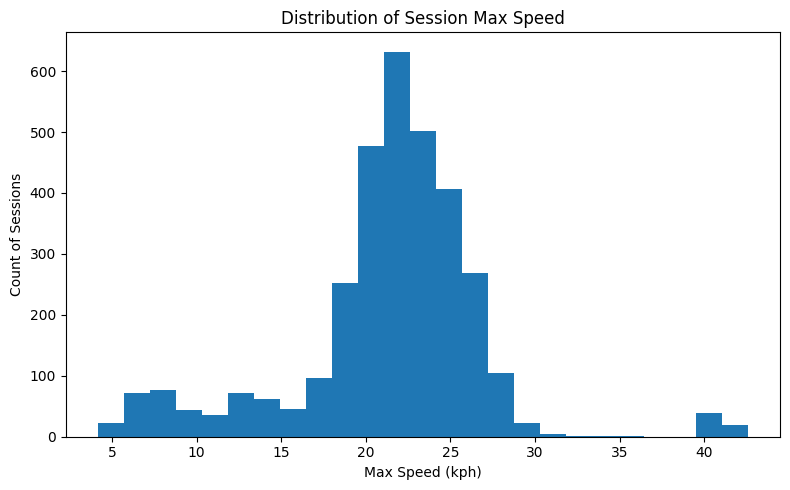

In [25]:
plt.figure(figsize=(8,5))
plt.hist(sessions["max_speed_kph"].dropna(), bins=25)
plt.title("Distribution of Session Max Speed")
plt.xlabel("Max Speed (kph)")
plt.ylabel("Count of Sessions")
plt.tight_layout()
plt.show()

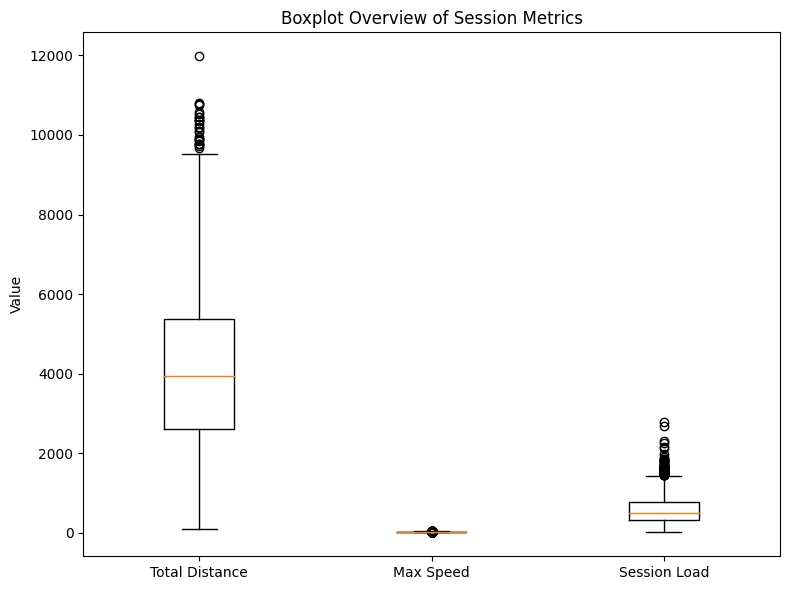

In [27]:
plt.figure(figsize=(8,6))
plt.boxplot([
    sessions["total_distance_m"].dropna(),
    sessions["max_speed_kph"].dropna(),
    sessions["session_load"].dropna()
], labels=["Total Distance", "Max Speed", "Session Load"])
plt.title("Boxplot Overview of Session Metrics")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [38]:
metrics = ["w_max_speed_kph", "w_total_distance", "w_session_load"]

for col in metrics + ["athlete_relative_age"]:
    agg[col] = pd.to_numeric(agg[col], errors="coerce")

agg = agg.dropna(subset=["athlete_relative_age"])
ages = sorted(agg["athlete_relative_age"].unique())

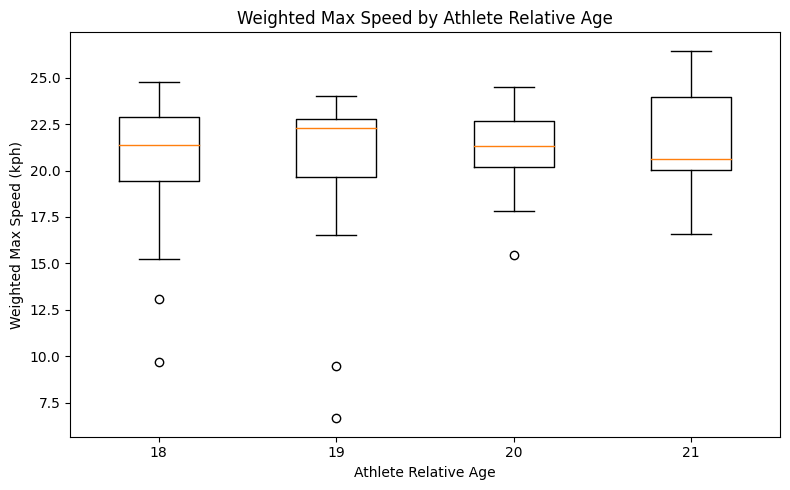

In [39]:
data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    for age in ages
]

plt.figure(figsize=(8,5))
plt.boxplot(data_to_plot, labels=[str(age) for age in ages])
plt.title("Weighted Max Speed by Athlete Relative Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

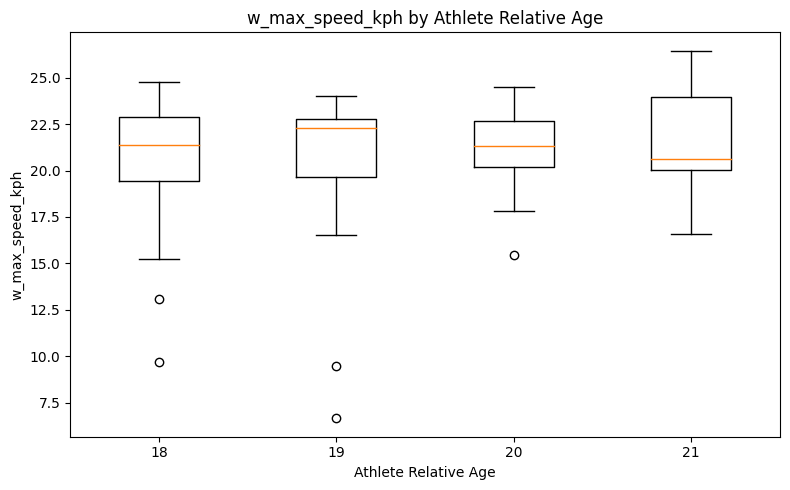

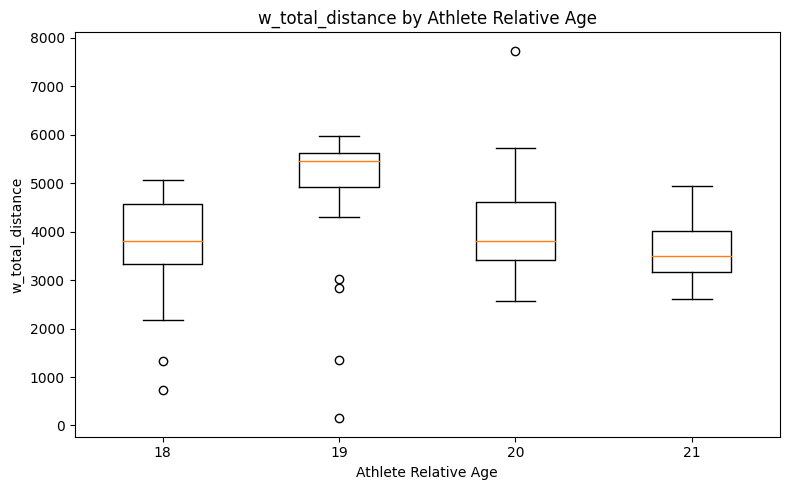

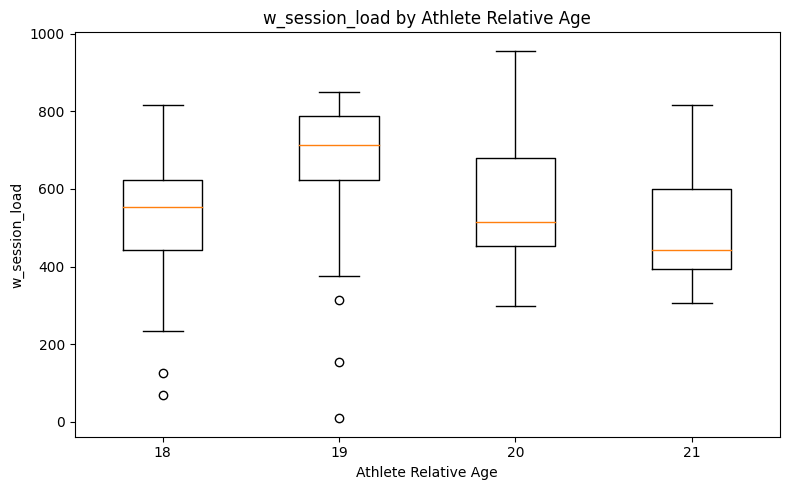

In [40]:
for metric in metrics:
    data_to_plot = [
        agg.loc[agg["athlete_relative_age"] == age, metric].dropna()
        for age in ages
    ]

    plt.figure(figsize=(8,5))
    plt.boxplot(data_to_plot, labels=[str(age) for age in ages])
    plt.title(f"{metric} by Athlete Relative Age")
    plt.xlabel("Athlete Relative Age")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

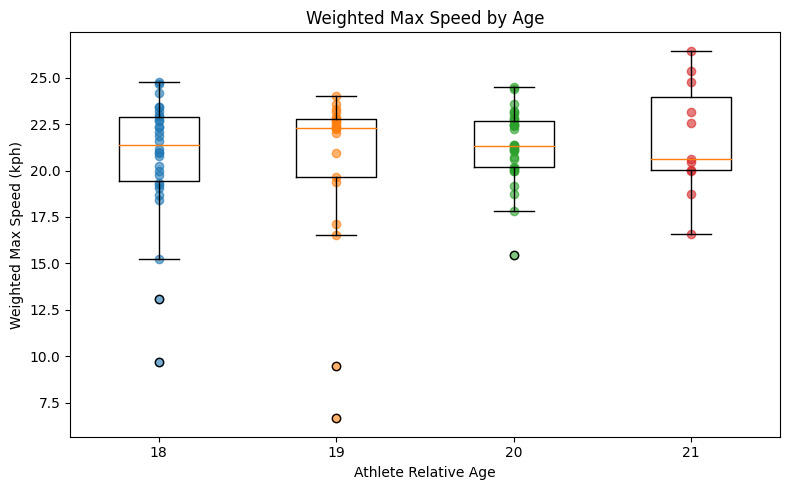

In [42]:
plt.figure(figsize=(8,5))

data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    for age in ages
]

plt.boxplot(data_to_plot, labels=[str(age) for age in ages])

for i, age in enumerate(ages, start=1):
    y = agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    x = [i] * len(y)
    plt.scatter(x, y, alpha=0.6)

plt.title("Weighted Max Speed by Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

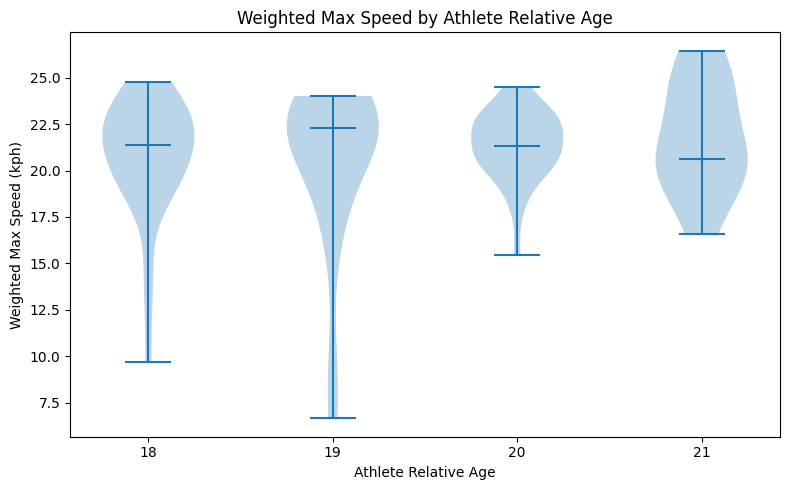

In [43]:
data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    for age in ages
]

plt.figure(figsize=(8,5))
plt.violinplot(data_to_plot, showmeans=False, showmedians=True)

plt.xticks(range(1, len(ages)+1), [str(age) for age in ages])
plt.title("Weighted Max Speed by Athlete Relative Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

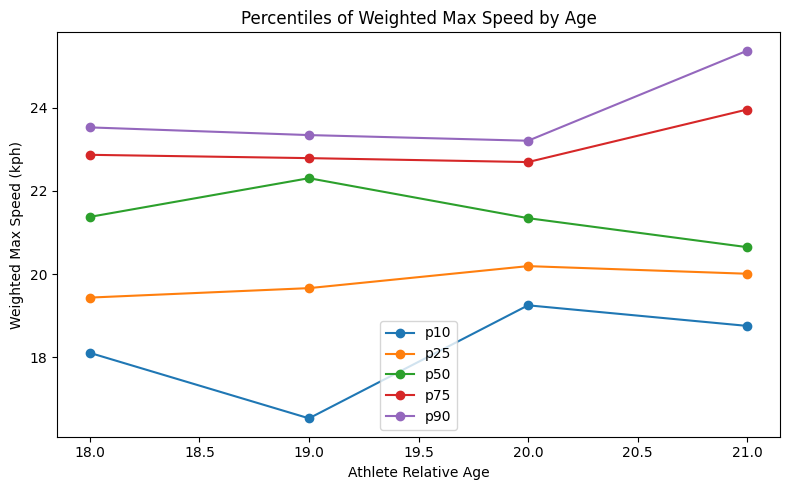

In [44]:
metric = "w_max_speed_kph"

percentile_summary = agg.groupby("athlete_relative_age")[metric].agg(
    p10=lambda x: x.quantile(0.10),
    p25=lambda x: x.quantile(0.25),
    p50=lambda x: x.quantile(0.50),
    p75=lambda x: x.quantile(0.75),
    p90=lambda x: x.quantile(0.90)
)

plt.figure(figsize=(8,5))
for col in percentile_summary.columns:
    plt.plot(percentile_summary.index, percentile_summary[col], marker='o', label=col)

plt.title("Percentiles of Weighted Max Speed by Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.legend()
plt.tight_layout()
plt.show()

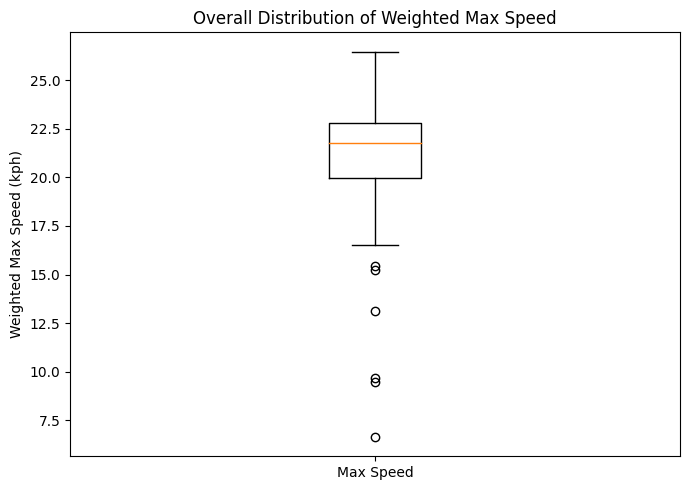

In [47]:
metric = "w_max_speed_kph"

plt.figure(figsize=(7,5))
plt.boxplot(agg[metric].dropna(), labels=["Max Speed"])
plt.title("Overall Distribution of Weighted Max Speed")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

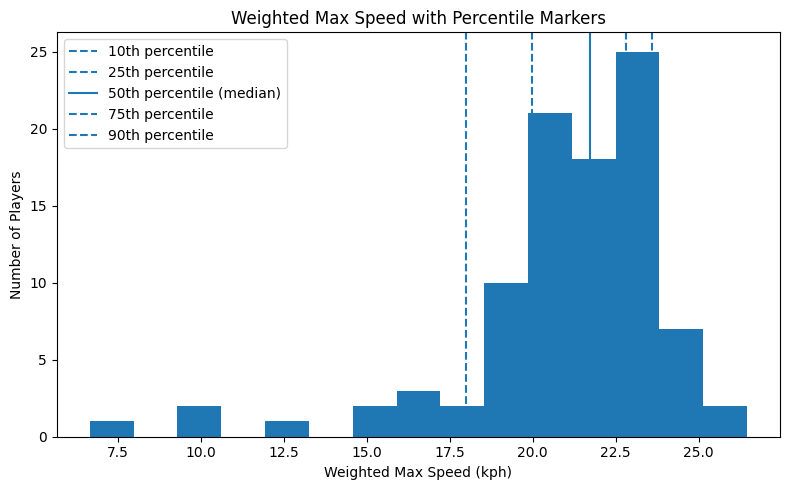

In [48]:
metric = "w_max_speed_kph"
x = agg[metric].dropna()

q10 = x.quantile(0.10)
q25 = x.quantile(0.25)
q50 = x.quantile(0.50)
q75 = x.quantile(0.75)
q90 = x.quantile(0.90)

plt.figure(figsize=(8,5))
plt.hist(x, bins=15)

plt.axvline(q10, linestyle="--", label="10th percentile")
plt.axvline(q25, linestyle="--", label="25th percentile")
plt.axvline(q50, linestyle="-",  label="50th percentile (median)")
plt.axvline(q75, linestyle="--", label="75th percentile")
plt.axvline(q90, linestyle="--", label="90th percentile")

plt.title("Weighted Max Speed with Percentile Markers")
plt.xlabel("Weighted Max Speed (kph)")
plt.ylabel("Number of Players")
plt.legend()
plt.tight_layout()
plt.show()

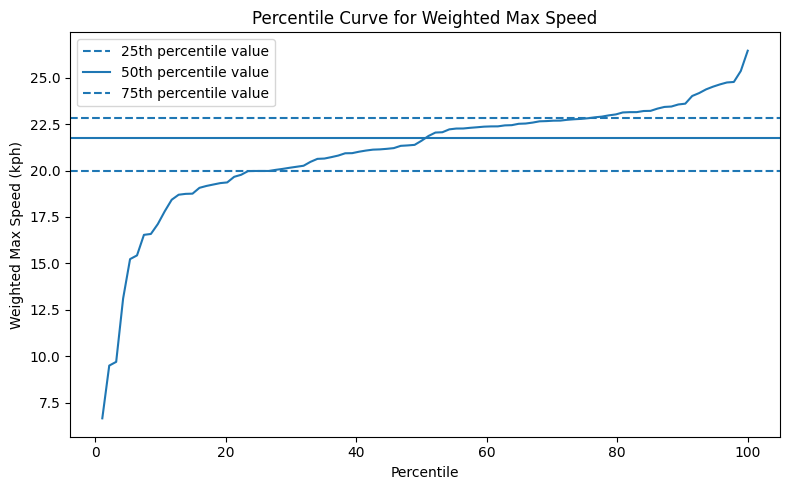

In [61]:
metric = "w_max_speed_kph"
x = agg[metric].dropna().sort_values().reset_index(drop=True)

percentiles = (x.rank(method="average", pct=True) * 100)

plt.figure(figsize=(8,5))
plt.plot(percentiles, x)
plt.axhline(x.quantile(0.25), linestyle="--", label="25th percentile value")
plt.axhline(x.quantile(0.50), linestyle="-", label="50th percentile value")
plt.axhline(x.quantile(0.75), linestyle="--", label="75th percentile value")

plt.title("Percentile Curve for Weighted Max Speed")
plt.xlabel("Percentile")
plt.ylabel("Weighted Max Speed (kph)")
plt.legend()
plt.tight_layout()
plt.show()

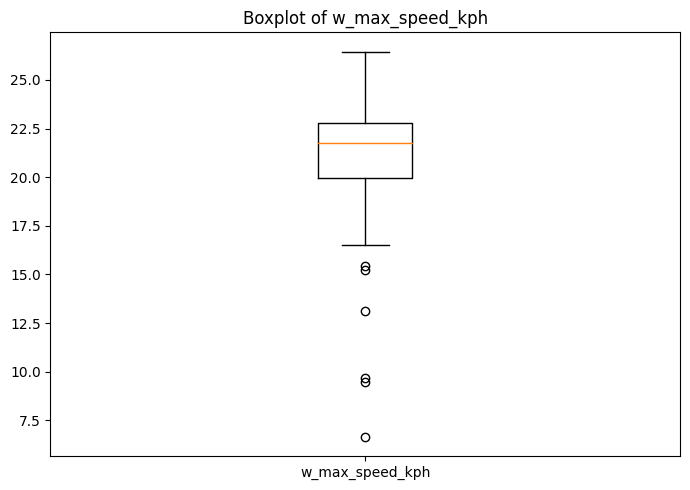

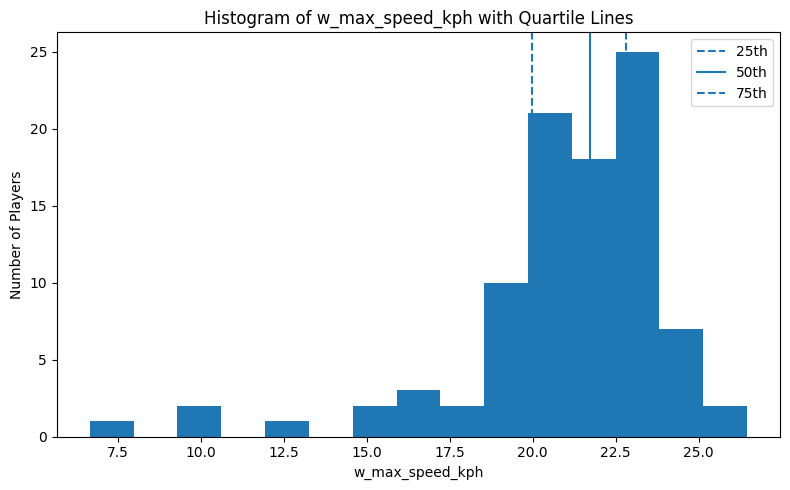

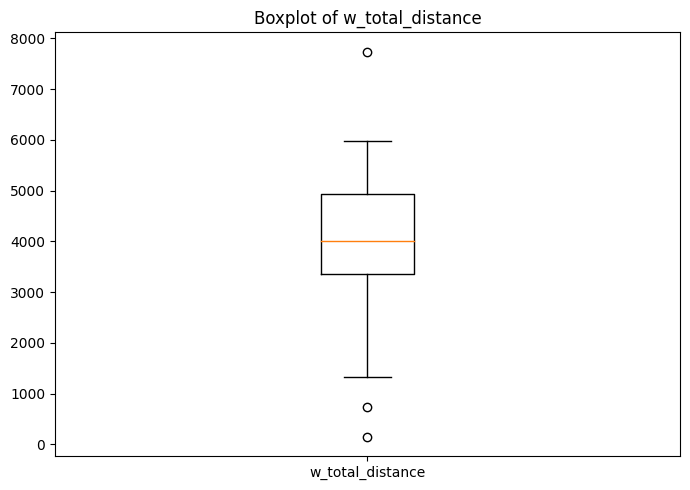

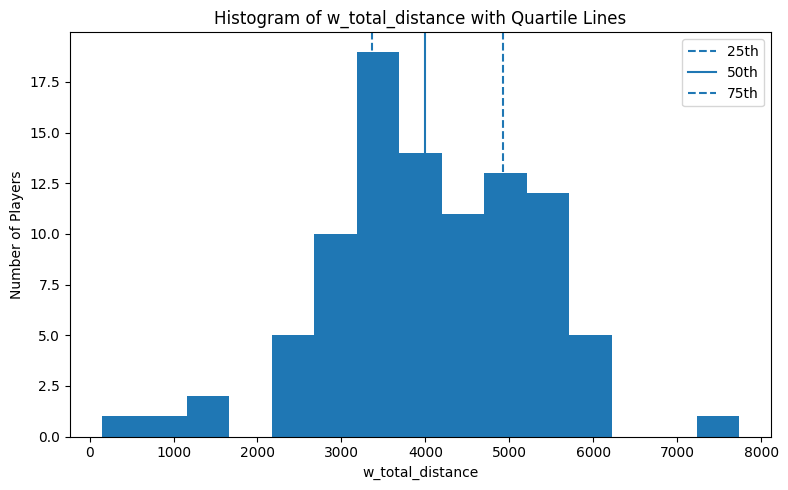

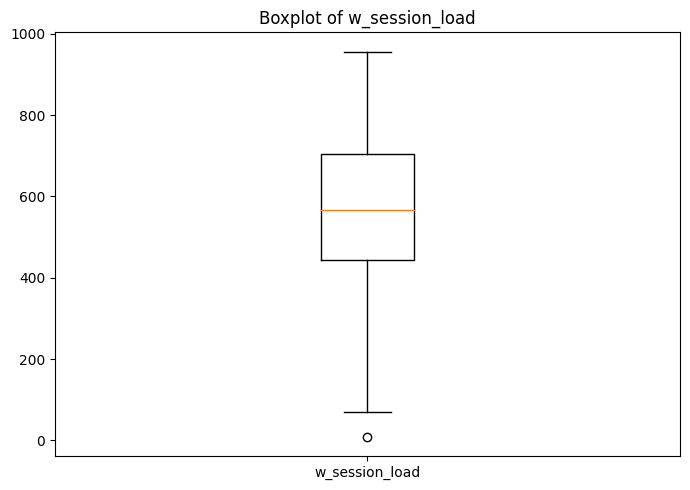

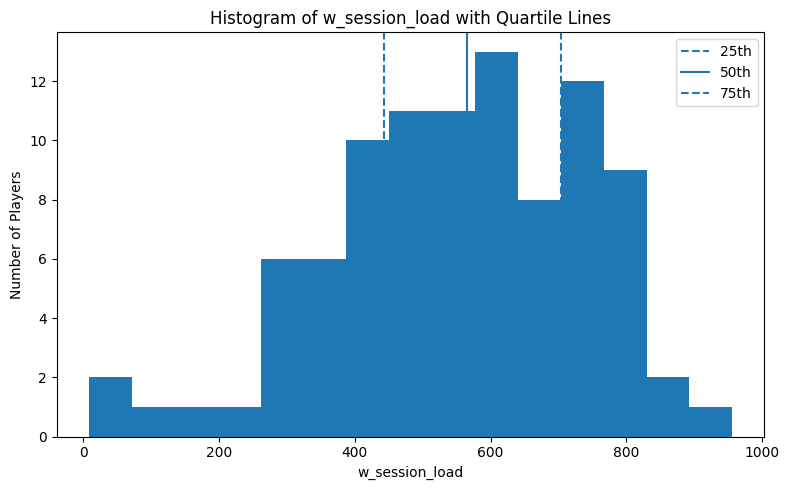

In [50]:
for metric in metrics:
    x = agg[metric].dropna()

    plt.figure(figsize=(7,5))
    plt.boxplot(x, labels=[metric])
    plt.title(f"Boxplot of {metric}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.hist(x, bins=15)
    plt.axvline(x.quantile(0.25), linestyle="--", label="25th")
    plt.axvline(x.quantile(0.50), linestyle="-", label="50th")
    plt.axvline(x.quantile(0.75), linestyle="--", label="75th")
    plt.title(f"Histogram of {metric} with Quartile Lines")
    plt.xlabel(metric)
    plt.ylabel("Number of Players")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [52]:
summary = agg[metrics].agg([
    lambda x: x.quantile(0.10),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.50),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90)
])

summary.index = ["p10", "p25", "p50", "p75", "p90"]
print(summary)

     w_max_speed_kph  w_total_distance  w_session_load
p10        17.995386       2854.927620      308.624156
p25        19.979793       3358.166891      442.572514
p50        21.736897       3997.565579      565.500179
p75        22.813217       4927.215605      703.339524
p90        23.593524       5586.403091      787.646702


In [57]:
for col in ["athlete_relative_age", "max_speed_kph", "session_load"]:
    sessions[col] = pd.to_numeric(sessions[col], errors="coerce")


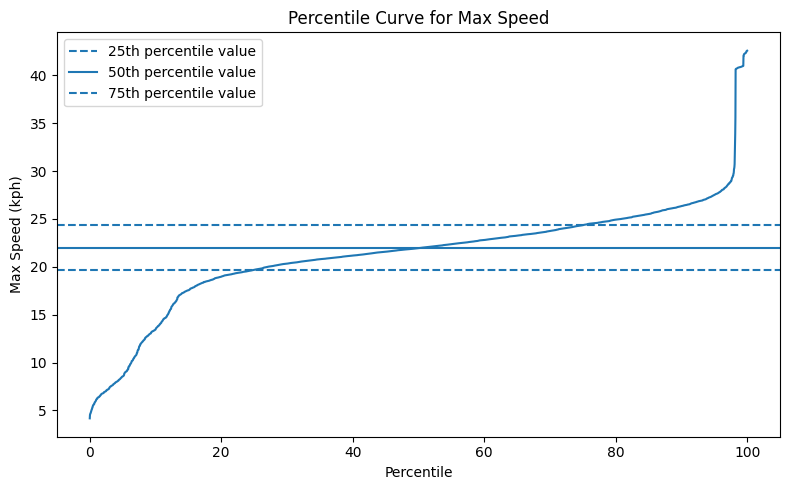

In [58]:
metric = "max_speed_kph"

x = sessions[metric].dropna().sort_values().reset_index(drop=True)
percentiles = x.rank(method="average", pct=True) * 100

plt.figure(figsize=(8,5))
plt.plot(percentiles, x)
plt.axhline(x.quantile(0.25), linestyle="--", label="25th percentile value")
plt.axhline(x.quantile(0.50), linestyle="-", label="50th percentile value")
plt.axhline(x.quantile(0.75), linestyle="--", label="75th percentile value")

plt.title("Percentile Curve for Max Speed")
plt.xlabel("Percentile")
plt.ylabel("Max Speed (kph)")
plt.legend()
plt.tight_layout()
plt.show()

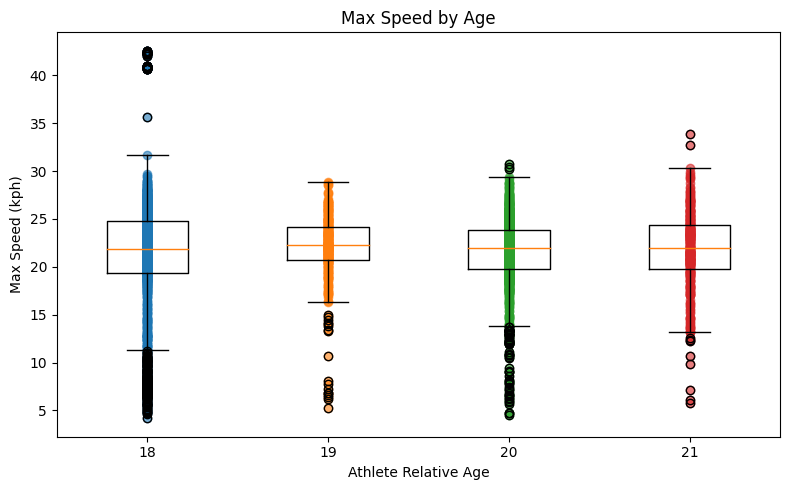

In [59]:
ages = sorted(sessions["athlete_relative_age"].dropna().unique())

plt.figure(figsize=(8,5))

data_to_plot = [
    sessions.loc[sessions["athlete_relative_age"] == age, "max_speed_kph"].dropna()
    for age in ages
]

plt.boxplot(data_to_plot, labels=[str(int(age)) for age in ages])

for i, age in enumerate(ages, start=1):
    y = sessions.loc[sessions["athlete_relative_age"] == age, "max_speed_kph"].dropna()
    x_vals = [i] * len(y)
    plt.scatter(x_vals, y, alpha=0.6)

plt.title("Max Speed by Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Max Speed (kph)")
plt.tight_layout()
plt.show()

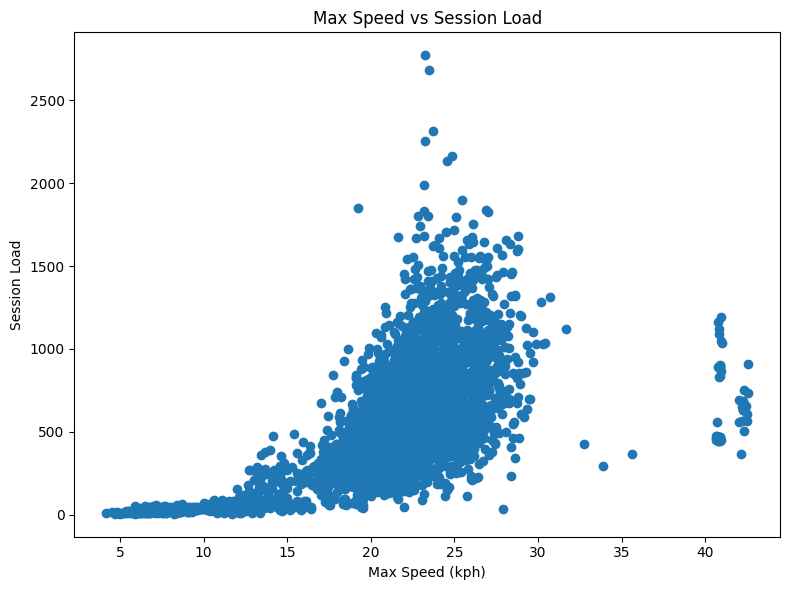

In [60]:
plt.figure(figsize=(8,6))
plt.scatter(sessions["max_speed_kph"], sessions["session_load"])
plt.title("Max Speed vs Session Load")
plt.xlabel("Max Speed (kph)")
plt.ylabel("Session Load")
plt.tight_layout()
plt.show()